In [1]:
import os
import pandas as pd

# Set dataset path
DATASET_PATH = "/kaggle/input/datasets/alonhaviv/the-maestro-dataset-v3-0-0/maestro-v3.0.0"

if not os.path.isdir(DATASET_PATH):
    raise FileNotFoundError(
        f"DATASET_PATH does not exist: {DATASET_PATH}. Update this path."
    )

print("Dataset path verified")

Dataset path verified


In [2]:
print("=== TOP LEVEL FILES ===")
top_files = os.listdir(DATASET_PATH)
print(top_files)

=== TOP LEVEL FILES ===
['2017', '2011', '2004', 'LICENSE', 'maestro-v3.0.0.csv', 'README', '2006', 'maestro-v3.0.0.json', '2014', '2013', '2009', '2015', '2008', '2018']


In [3]:
print("=== FIND METADATA FILE ===")

csv_path = None
for f in top_files:
    if f.endswith(".csv"):
        csv_path = os.path.join(DATASET_PATH, f)
        print("Found CSV:", csv_path)
        break

if csv_path is None:
    raise FileNotFoundError("No metadata CSV file found.")

=== FIND METADATA FILE ===
Found CSV: /kaggle/input/datasets/alonhaviv/the-maestro-dataset-v3-0-0/maestro-v3.0.0/maestro-v3.0.0.csv


In [4]:
print("=== LOAD METADATA ===")

df = pd.read_csv(csv_path)

print("Columns:")
print(df.columns)

print("\nFirst 5 rows:")
df.head()

=== LOAD METADATA ===
Columns:
Index(['canonical_composer', 'canonical_title', 'split', 'year',
       'midi_filename', 'audio_filename', 'duration'],
      dtype='object')

First 5 rows:


,canonical_composer,canonical_title,split,year,midi_filename,audio_filename,duration
0,Alban Berg,Sonata Op. 1,train,2018,2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R...,2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R...,698.661160
1,Alban Berg,Sonata Op. 1,train,2008,2008/MIDI-Unprocessed_03_R2_2008_01-03_ORIG_MI...,2008/MIDI-Unprocessed_03_R2_2008_01-03_ORIG_MI...,759.518471
2,Alban Berg,Sonata Op. 1,train,2017,2017/MIDI-Unprocessed_066_PIANO066_MID--AUDIO-...,2017/MIDI-Unprocessed_066_PIANO066_MID--AUDIO-...,464.649433
3,Alexander Scriabin,"24 Preludes Op. 11, No. 13-24",train,2004,2004/MIDI-Unprocessed_XP_21_R1_2004_01_ORIG_MI...,2004/MIDI-Unprocessed_XP_21_R1_2004_01_ORIG_MI...,872.640588
4,Alexander Scriabin,"3 Etudes, Op. 65",validation,2006,2006/MIDI-Unprocessed_17_R1_2006_01-06_ORIG_MI...,2006/MIDI-Unprocessed_17_R1_2006_01-06_ORIG_MI...,397.857508


## Task 1: LSTM Autoencoder for MAESTRO (Keras)

This notebook:
1. Converts MAESTRO MIDI files to fixed-length piano-roll sequences
2. Trains an LSTM autoencoder with MSE loss
3. Plots reconstruction loss curves
4. Reconstructs and saves 5 MIDI samples from the test split

In [5]:
# Run once if needed
%pip install -q tensorflow pretty_midi matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 40.5 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pretty_midi
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Pipeline settings
TIMESTEPS = 128 # 128 time steps covers 8 seconds of music at fs=16
FS = 16
N_FEATURES = 88 # 88 piano keys
LATENT_DIM = 64
LSTM_UNITS = 256
BATCH_SIZE = 64 # Recommended by guide
EPOCHS = 50
LEARNING_RATE = 0.001
MAX_TRAIN = 1200
MAX_VAL = 200
MAX_TEST = 200

OUTPUT_DIR = "generated_midi_lstm_ae"
os.makedirs(OUTPUT_DIR, exist_ok=True)

if 'df' not in globals() or 'DATASET_PATH' not in globals():
    raise RuntimeError("Run Cell 1 first so df and DATASET_PATH are available.")

print("TensorFlow version:", tf.__version__)
print("Rows in metadata:", len(df))
print("Output directory:", os.path.abspath(OUTPUT_DIR))

2026-05-03 04:37:38.550884: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777783058.740599      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777783058.797499      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777783059.224026      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777783059.224074      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777783059.224076      57 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
Rows in metadata: 1276
Output directory: /kaggle/working/generated_midi_lstm_ae


In [7]:
def midi_to_windows(midi_path, timesteps=TIMESTEPS, fs=FS):
    try:
        midi_obj = pretty_midi.PrettyMIDI(midi_path)
        # Get piano roll, shape is (128, T)
        roll = midi_obj.get_piano_roll(fs=fs)
        # Slice pitch rows 21 through 108 (88 keys)
        roll = roll[21:109, :]
        # Binarize and transpose to (T, 88)
        roll = (roll > 0).astype(np.float32).T
    except Exception:
        return []

    if roll.shape[0] < timesteps:
        return []
    
    windows = []
    # Segment into windows of length `timesteps`
    for start in range(0, roll.shape[0] - timesteps + 1, timesteps):
        window = roll[start:start+timesteps, :]
        # Filter sparse windows: discard if < 2% of cells are active
        if np.mean(window) >= 0.02:
            windows.append(window)

    return windows

def build_split_array(split_df, max_items):
    sequences = []
    paths = []
    for rel_path in split_df["midi_filename"].tolist()[:max_items]:
        full_path = os.path.join(DATASET_PATH, rel_path)
        if not os.path.exists(full_path):
            continue
        windows = midi_to_windows(full_path)
        for w in windows:
            sequences.append(w)
            paths.append(full_path)

    if not sequences:
        raise RuntimeError("No valid MIDI sequences found for this split.")

    return np.stack(sequences, axis=0), paths

train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df = df[df["split"].isin(["validation", "val"])].reset_index(drop=True)
test_df = df[df["split"] == "test"].reset_index(drop=True)

X_train, train_paths = build_split_array(train_df, MAX_TRAIN)
X_val, val_paths = build_split_array(val_df, MAX_VAL) if len(val_df) > 0 else (None, [])
X_test, test_paths = build_split_array(test_df, MAX_TEST)

if X_val is None:
    split_idx = int(0.9 * len(X_train))
    X_train, X_val = X_train[:split_idx], X_train[split_idx:]

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

# Create tf.data.Datasets
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, X_train)).shuffle(len(X_train)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, X_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, X_test)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


X_train: (62689, 128, 88)
X_val  : (7876, 128, 88)
X_test : (7792, 128, 88)


I0000 00:00:1777783401.217651      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [8]:
inputs = layers.Input(shape=(TIMESTEPS, N_FEATURES), name="encoder_input")

x = layers.LSTM(
    LSTM_UNITS, 
    return_sequences=True, 
    name="encoder_lstm_1"
)(inputs)

encoded = layers.LSTM(
    LSTM_UNITS, 
    name="encoder_lstm_2"
)(x)

latent = layers.Dense(LATENT_DIM, activation="tanh", name="latent_vector")(encoded)

repeated = layers.RepeatVector(TIMESTEPS, name="repeat_latent")(latent)

y = layers.LSTM(
    LSTM_UNITS, 
    return_sequences=True,
    name="decoder_lstm_1"
)(repeated)

decoded = layers.LSTM(
    LSTM_UNITS, 
    return_sequences=True,
    name="decoder_lstm_2"
)(y)

outputs = layers.TimeDistributed(layers.Dense(N_FEATURES), name="reconstruction_logits")(decoded)

autoencoder = Model(inputs, outputs, name="lstm_autoencoder")

#loss_fn = tf.keras.losses.BinaryFocalCrossentropy(from_logits=True, apply_class_balancing=True, alpha=0.9, gamma=2.0)

autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE), loss='mse')

autoencoder.summary()

early_stop = EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1)
history = autoencoder.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[early_stop],
    verbose=1,
)

print("Best validation loss:", float(np.min(history.history["val_loss"])))

Model: "lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 128, 88)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_1 (LSTM)           │ (None, 128, 256)       │       353,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_2 (LSTM)           │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_latent (RepeatVector)    │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_1 (LSTM)           │ (None, 128, 256)       │       328,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_2 (LSTM)           │ (None, 128, 256)       │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction_logits           │ (None, 128, 88)        │        22,616 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,771,672 (6.76 MB)

 Trainable params: 1,771,672 (6.76 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


I0000 00:00:1777783430.085723     133 cuda_dnn.cc:529] Loaded cuDNN version 91002


980/980 ━━━━━━━━━━━━━━━━━━━━ 82s 71ms/step - loss: 0.0460 - val_loss: 0.0370
Epoch 2/50
980/980 ━━━━━━━━━━━━━━━━━━━━ 67s 68ms/step - loss: 0.0367 - val_loss: 0.0355
Epoch 3/50
980/980 ━━━━━━━━━━━━━━━━━━━━ 67s 69ms/step - loss: 0.0357 - val_loss: 0.0350
Epoch 4/50
980/980 ━━━━━━━━━━━━━━━━━━━━ 67s 69ms/step - loss: 0.0354 - val_loss: 0.0350
Epoch 5/50
980/980 ━━━━━━━━━━━━━━━━━━━━ 67s 68ms/step - loss: 0.0355 - val_loss: 0.0349
Epoch 6/50
980/980 ━━━━━━━━━━━━━━━━━━━━ 67s 69ms/step - loss: 0.0352 - val_loss: 0.0336
Epoch 7/50
980/980 ━━━━━━━━━━━━━━━━━━━━ 67s 69ms/step - loss: 0.0338 - val_loss: 0.0327
Epoch 8/50
980/980 ━━━━━━━━━━━━━━━━━━━━ 67s 69ms/step - loss: 0.0330 - val_loss: 0.0318
Epoch 9/50
980/980 ━━━━━━━━━━━━━━━━━━━━ 67s 69ms/step - loss: 0.0314 - val_loss: 0.0305
Epoch 10/50
980/980 ━━━━━━━━━━━━━━━━━━━━ 67s 69ms/step - loss: 0.0300 - val_loss: 0.0290
Epoch 11/50
980/980 ━━━━━━━━━━━━━━━━━━━━ 67s 68ms/step - loss: 0.0284 - val_loss: 0.0278
Epoch 12/50
980/980 ━━━━━━━━━━━━━━━━━━━━ 

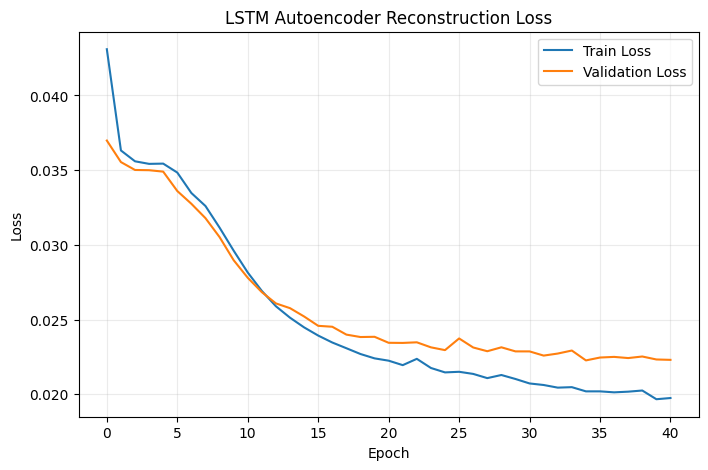

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Autoencoder Reconstruction Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [10]:
def roll_to_pretty_midi(prob_roll, fs=FS, threshold=0.35, min_note_steps=2, max_notes_per_step=10):
    if prob_roll.ndim != 2 or prob_roll.shape[1] != 88:
        raise ValueError("Expected roll shape (timesteps, 88).")

    filtered = np.zeros_like(prob_roll, dtype=np.float32)
    if max_notes_per_step is None or max_notes_per_step >= 88:
        filtered = prob_roll.copy()
    else:
        for t in range(prob_roll.shape[0]):
            row = prob_roll[t]
            idx = np.argpartition(row, -max_notes_per_step)[-max_notes_per_step:]
            filtered[t, idx] = row[idx]

    binary_roll = (filtered >= threshold).astype(np.int32).T
    seconds_per_step = 1.0 / fs
    pm = pretty_midi.PrettyMIDI()
    piano = pretty_midi.Instrument(program=0, name="acoustic_piano")

    for pitch_idx in range(88):
        active = binary_roll[pitch_idx]
        actual_pitch = pitch_idx + 21 # Shift pitch back to map 0 to 21 (A0)
        
        start_t = None
        for t, val in enumerate(active):
            if val == 1 and start_t is None:
                start_t = t
            elif val == 0 and start_t is not None:
                dur_steps = t - start_t
                if dur_steps >= min_note_steps:
                    vel = int(np.clip(40 + 87 * float(np.mean(filtered[start_t:t, pitch_idx])), 40, 127))
                    piano.notes.append(pretty_midi.Note(velocity=vel, pitch=actual_pitch, start=start_t * seconds_per_step, end=t * seconds_per_step))
                start_t = None

        if start_t is not None:
            dur_steps = len(active) - start_t
            if dur_steps >= min_note_steps:
                vel = int(np.clip(40 + 87 * float(np.mean(filtered[start_t:, pitch_idx])), 40, 127))
                piano.notes.append(pretty_midi.Note(velocity=vel, pitch=actual_pitch, start=start_t * seconds_per_step, end=len(active) * seconds_per_step))

    pm.instruments.append(piano)
    return pm

# Create decoder model to bypass encoder setup
decoder_input = layers.Input(shape=(LATENT_DIM,))
x = autoencoder.get_layer("repeat_latent")(decoder_input)
x = autoencoder.get_layer("decoder_lstm_1")(x)
x = autoencoder.get_layer("decoder_lstm_2")(x)
decoder_output = autoencoder.get_layer("reconstruction_logits")(x)

# Apply sigmoid here since model outputs logits
decoder_output = tf.keras.activations.sigmoid(decoder_output)

decoder_model = Model(decoder_input, decoder_output, name="decoder_only")

n_samples = 5
print(f"Generating {n_samples} random MIDI files from standard normal latent space...")
random_latents = np.random.normal(0, 1, size=(n_samples, LATENT_DIM))
generated_rolls = decoder_model.predict(random_latents, verbose=0)

for i in range(n_samples):
    recon_roll = generated_rolls[i]
    reconstructed_pm = roll_to_pretty_midi(recon_roll, fs=FS, threshold=0.25, min_note_steps=2, max_notes_per_step=10)
    out_path = os.path.join(OUTPUT_DIR, f"generated_sample_{i+1}.mid")
    reconstructed_pm.write(out_path)
    n_notes = len(reconstructed_pm.instruments[0].notes)
    print(f"[{i+1}] Saved: {out_path}")
    print(f"    Notes in output: {n_notes}")

print("Done. Check generated files in:", os.path.abspath(OUTPUT_DIR))

Generating 5 random MIDI files from standard normal latent space...
[1] Saved: generated_midi_lstm_ae/generated_sample_1.mid
    Notes in output: 26
[2] Saved: generated_midi_lstm_ae/generated_sample_2.mid
    Notes in output: 34
[3] Saved: generated_midi_lstm_ae/generated_sample_3.mid
    Notes in output: 15
[4] Saved: generated_midi_lstm_ae/generated_sample_4.mid
    Notes in output: 21
[5] Saved: generated_midi_lstm_ae/generated_sample_5.mid
    Notes in output: 36
Done. Check generated files in: /kaggle/working/generated_midi_lstm_ae
